In [15]:
import pandas as pd 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sentence_transformers import SentenceTransformer
import torch
from torch.nn import functional as F
from transformers import AutoTokenizer, AutoModelForMaskedLM
import umap.umap_ as umap
import numpy as np

df = pd.read_csv("/Users/iseult/Desktop/Trait_Assignment/EPIraction_selenoproteins_FDR_0.00001.csv")

# Remove irrelevant rows 
df = df[~df['title'].str.contains('Job coding', case=False, na=False)]
df = df[~df['title'].str.contains('Job SOC coding:', case=False, na=False)]
df = df[~df['title'].str.contains('Job code - deduced:', case=False, na=False)]

In [16]:
category_descriptions = { 
    # Cardiovascular
    "Cardiovascular": ["coronary", "heart failure", "myocardial infarction", "cardiomyopathy", "arrhythmia", "hypertension", "stroke", "atherosclerosis", "anemia", "thrombosis", "blood", "heart rate", "heart", "arteries", "veins", "atria", "ventricles", "aorta", "valves", "circulation", "platelet"],

    # Metabolic 
    "Metabolic": ["diabetes", "obesity", "hyperglycemia", "dyslipidemia", "hypercholesterolemia", "insulin resistance", "fatty liver", "insulin", "glucose", "body mass index", "mass", "weight", "height", "fat free mass", "metabolic", "metabolic rate"],
    
    # Endocrine
    "Thyroid Disorders": ["hyperthyroidism", "hypothyroidism", "thyroiditis", "goiter", "graves", "hashimoto", "gout"],

    # Respiratory
    "Respiratory Disorders": ["pneumonia", "asthma", "lung capacity", "breathing problems", "bronchitis", "lung", "breathing", "respiration", "eosinophill"],

    # Immune / Inflammatory
    "Autoimmune Disorders": ["crohn", "ulcerative colitis", "immunodeficiency", "autoimmune", "cytokine", "immune", "lymphocyte", "leukocytes", "cytotoxic T cells", "dendritic cells", "helper T cells", "macrophages", "arthritis", "psoriasis", "inflammation"],

    # Infection
    "Infection": ["infection", "fever", "viral", "bacterial", "parasitic"],
    
    # Cancer
    "Cancer / Neoplastic Diseases": ["cancer", "carcinoma", "sarcoma", "leukemia", "lymphoma", "melanoma", "tumor", "metastasis", "oncogene", "neoplasm"],

    # Neurological / Psychiatric
    "Neurodegenerative": ["alzheimer", "parkinson", "dementia", "hypomyelination", "senility", "neurodegenerative", "memory", "brain", "cognition", "neuron", "epilepsy", "autism"],
    "Psychiatric": ["mental health", "schizophrenia", "depression", "bipolar"],
    
    # Developmental
    "Developmental Disorders": ["dysplasia", "spastic", "developmental delay", "skeletal dysplasia", "craniofacial anomaly", "cleft", "microcephaly"],

    # Reproductive / Fertility
    "Reproductive / Fertility Disorders": ["infertility", "amenorrhea", "pcos", "endometriosis", "sperm abnormality", "ovarian failure", "testicular dysfunction"],

    # Musculoskeletal
    "Musculoskeletal Disorders": ["osteoporosis", "sciatica", "spondylopathy", "myopathy", "muscular dystrophy", "arthritis", "bone fracture", "muscle", "bone", "injury"],

    # Renal
    "Renal Disorders": ["incontinence", "cystitis", "urinary tract infection", "kidney disease"],

    # Lifestyle / Diet
    "Diet": ["alcohol", "sugar", "smoking", "obesity"],

    # Medication
    "Medication": ["treatment", "dosage", "prescribed"],

    # Catch-all / lifestyle
    "Lifestyle / Behavioral": ["exercise", "sleep", "nutrition", "wellbeing"],
    
    "Environmental Exposure": ["air pollution", "noise", "sunlight exposure", "chemical exposure"],

    "General Health / Anthropometric": ["height", "weight", "BMI", "lean mass", "fat mass"],

    "Socioeconomic / Demographic": ["income", "education level", "employment status", "neighborhood deprivation index"],

}

In [17]:
# Load a biomedical embedding model
#model = SentenceTransformer('microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext')
model = SentenceTransformer('menadsa/S-BlueBERT')
# Create the category embeddings
category_names = list(category_descriptions.keys())
category_texts = list(category_descriptions.values())
category_embeddings = model.encode(category_texts, convert_to_tensor=True)

traits = df['title'].astype(str).tolist()
trait_embeddings = model.encode(traits, convert_to_tensor=True)

In [18]:
trait_embeddings = F.normalize(trait_embeddings, p=2, dim=1)
category_embeddings = F.normalize(category_embeddings, p=2, dim=1)

# Compute cosine similarity between each trait and each category
similarities = trait_embeddings @ category_embeddings.T

# Find best match and its similarity score
max_sim, best_idx = torch.max(similarities, dim=1)
best_idx = best_idx.cpu().numpy()
max_sim = max_sim.cpu().numpy()

# Threshold for confident assignment
threshold = 0.30  # you can tune this (0.25–0.40 often works well)

# Assign categories (or leave unassigned)
df['Predicted_Category'] = [
    category_names[i] if s > threshold else "Unassigned"
    for i, s in zip(best_idx, max_sim)
]
df['Category_Similarity'] = max_sim

df.to_csv("/Users/iseult/Desktop/EPIraction_selenoproteins_FDR_0.00001_predicted_categories.csv")

/Users/iseult/.python/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


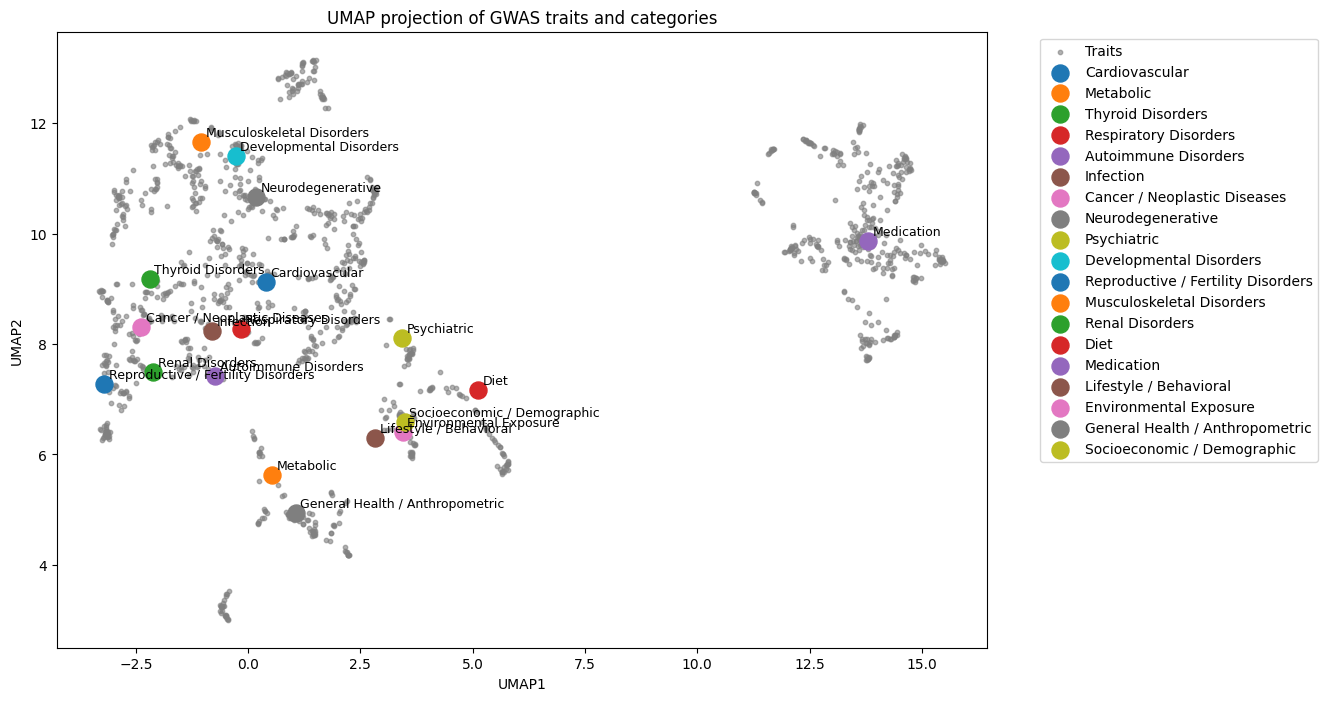

In [19]:
# Convert embeddings to numpy
trait_emb_np = trait_embeddings.cpu().numpy()
category_emb_np = category_embeddings.cpu().numpy()

# Concatenate traits + categories for a shared projection
all_embeddings = np.vstack([trait_emb_np, category_emb_np])

# Fit UMAP (you can adjust n_neighbors / min_dist)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(all_embeddings)

# Split back into traits and categories
trait_2d = embedding_2d[:len(trait_emb_np)]
category_2d = embedding_2d[len(trait_emb_np):]

# Plot
plt.figure(figsize=(12, 8))

# Plot traits
plt.scatter(trait_2d[:, 0], trait_2d[:, 1], s=10, c='gray', alpha=0.6, label='Traits')

# Plot categories
for i, name in enumerate(category_names):
    plt.scatter(category_2d[i, 0], category_2d[i, 1], s=150, label=name)
    plt.text(category_2d[i, 0]+0.1, category_2d[i, 1]+0.1, name, fontsize=9)

plt.title("UMAP projection of GWAS traits and categories")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.savefig("/Users/iseult/Desktop/Trait_Assignment/UMAP.pdf")


/var/folders/kl/s2thrg3x7xv8yn26zr1j_pd80000gn/T/ipykernel_3061/3468463074.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle


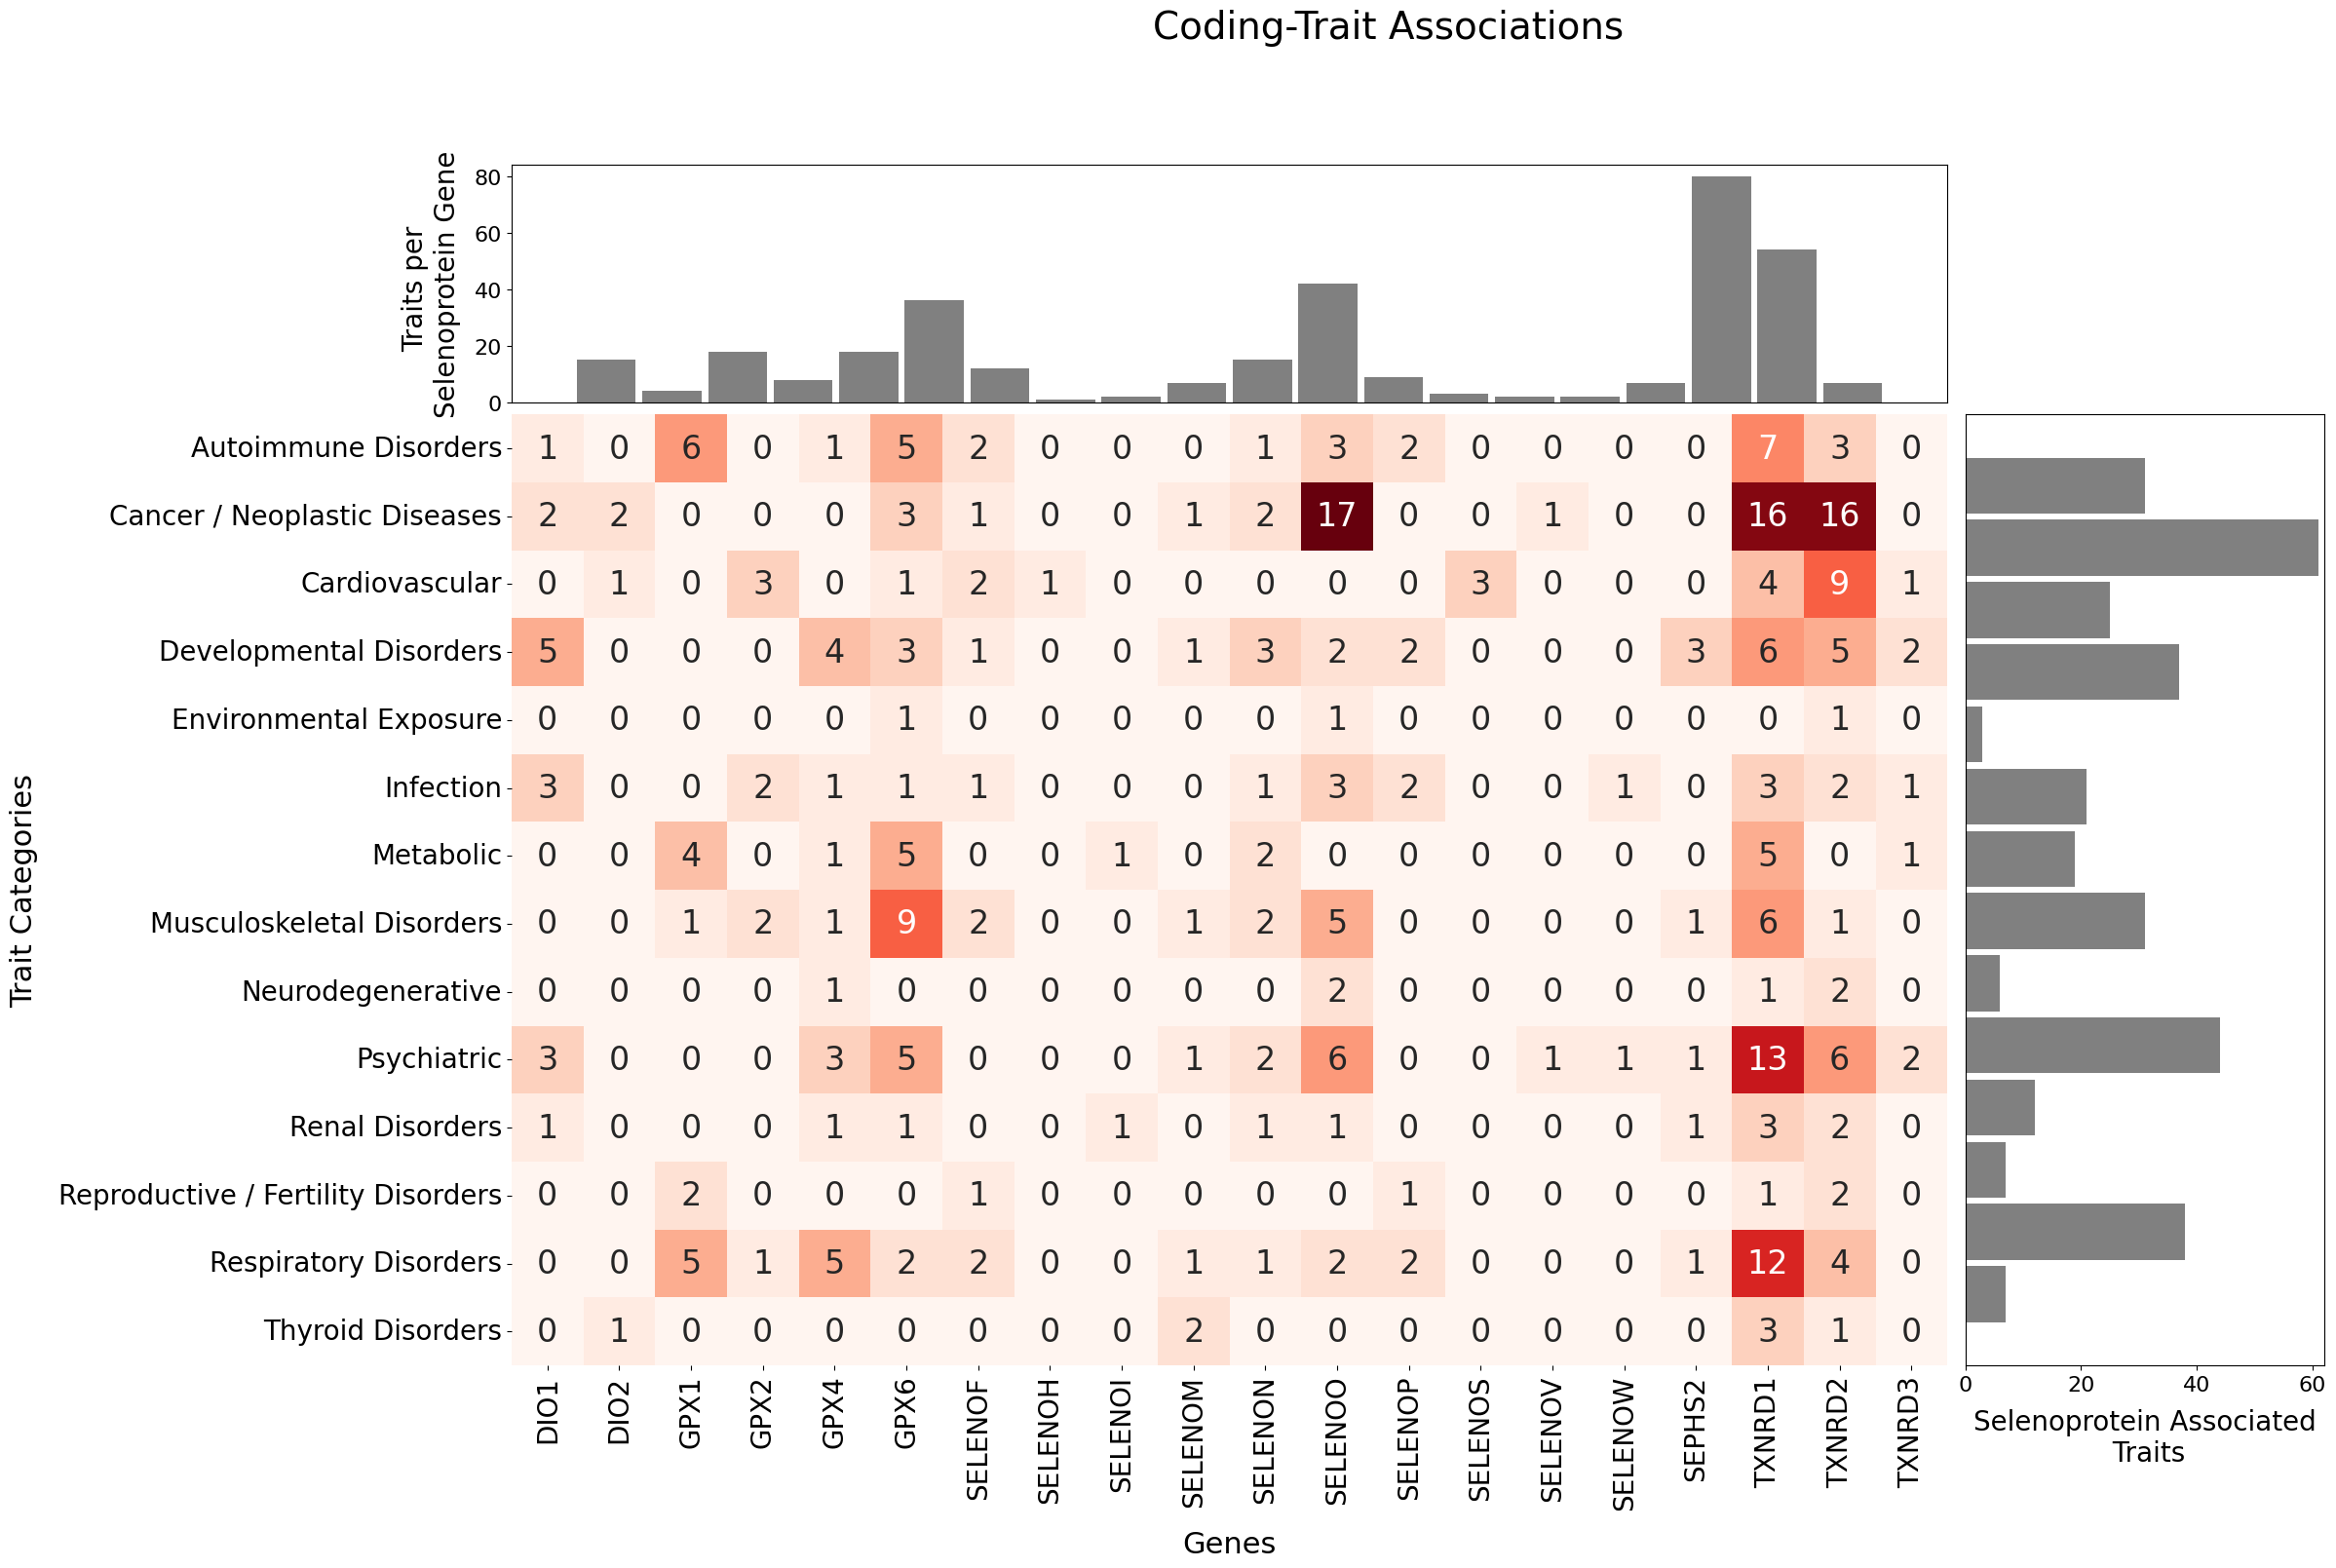

In [21]:
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Remove unassigned traits
df = df[df['Predicted_Category'] != 'Unassigned']
df = df[df['Predicted_Category'] != 'Medication']
df = df[df['Predicted_Category'] != 'Diet']
df = df[df['Predicted_Category'] != 'General Health / Anthropometric']
df = df[df['Predicted_Category'] != 'Lifestyle / Behavioral']
df = df[df['Predicted_Category'] != 'Socioeconomic / Demographic']

# Expand rows with multiple genes
df_expanded = df.assign(coding_list=df['coding list'].str.split(',')).explode('coding_list')
df_expanded['coding_list'] = df_expanded['coding_list'].str.strip()

# Pivot table for heatmap
heatmap_data = pd.crosstab(df_expanded['Predicted_Category'], df_expanded['coding_list'])

# Marginal counts
y_counts = heatmap_data.sum(axis=1)  # genes per category
x_counts = heatmap_data.sum(axis=0)  # categories per gene

# Figure and GridSpec: make width/height ratios larger for bars
fig = plt.figure(figsize=(24, 16))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.0, 0.25], height_ratios=[0.25, 1.0],
                       wspace=0.02, hspace=0.02)

# Heatmap
ax_heatmap = fig.add_subplot(gs[1, 0])
sns.heatmap(
    heatmap_data, cmap='Reds', annot=True, cbar=False, ax=ax_heatmap,
    annot_kws={"fontsize": 24}
)

# Cell positions
x_pos = [i + 0.5 for i in range(heatmap_data.shape[1])]
y_pos = [i + 0.5 for i in range(heatmap_data.shape[0])]

# Top bar chart using slightly wider bars
ax_top = fig.add_subplot(gs[0, 0])
ax_top.bar(x_pos, x_counts.values, width=0.9, color='gray', align='center')
ax_top.set_xticks([])
ax_top.set_ylabel('Traits per \nSelenoprotein Gene', fontsize=20, labelpad=10)
ax_top.tick_params(axis='y', labelsize=16)

# Right-hand side using broken_barh for exact alignment
ax_right = fig.add_subplot(gs[1, 1])
for i, val in enumerate(y_counts.values):
    ax_right.broken_barh([(0, val)], (i, 0.9), facecolors='gray')
ax_right.set_yticks([])
ax_right.set_xlabel('Selenoprotein Associated\n Traits', fontsize=20, labelpad=10)
ax_right.tick_params(axis='x', labelsize=16)
ax_right.set_xlim(0, max(y_counts)+1)
ax_right.invert_yaxis()

# Heatmap axis labels
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=90, fontsize=20)
ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), rotation=0, fontsize=20)
ax_heatmap.set_xlabel("Genes", fontsize=22, labelpad=15)
ax_heatmap.set_ylabel("Trait Categories", fontsize=22, labelpad=15)

# Optional: Add a title for the full figure
fig.suptitle("Coding-Trait Associations", fontsize=28, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.savefig("/Users/iseult/Desktop/Trait_Assignment/coding_trait_associations_better.pdf")
plt.show()

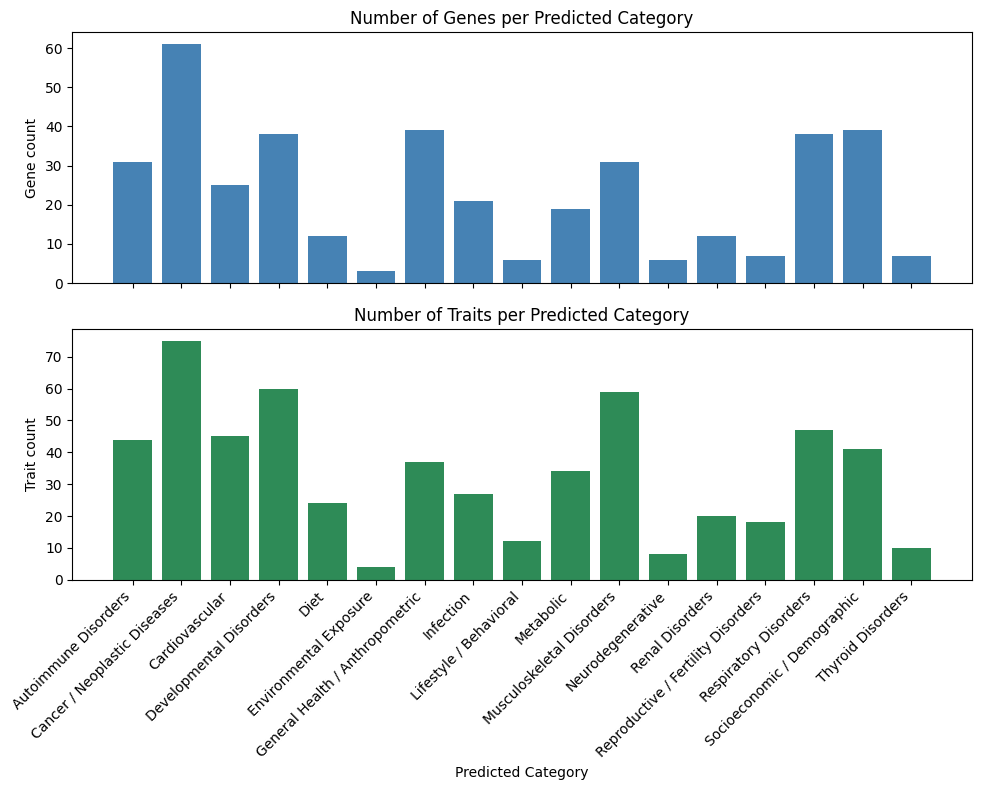

In [15]:
df_expanded = df_expanded[df_expanded['Predicted_Category'] != 'Unassigned']

# --- 1️⃣ Count genes per category ---
# Since coding_list is a single gene per row after expansion,
# just count how many rows per category
gene_counts = df_expanded.groupby("Predicted_Category")["coding_list"].nunique()  # counts unique genes per category
# alternatively, if duplicates across traits are allowed, use .count()
gene_counts_all = df_expanded.groupby("Predicted_Category")["coding_list"].count()

# --- 2️⃣ Count traits per category ---
trait_counts = df_expanded.groupby("Predicted_Category")["title"].nunique()

# --- 3️⃣ Combine for plotting ---
counts_df = pd.DataFrame({
    "Gene count": gene_counts_all,
    "Trait count": trait_counts
}).fillna(0)

# --- 4️⃣ Plot two stacked histograms (shared x-axis) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gene count histogram
axes[0].bar(counts_df.index, counts_df["Gene count"], color="steelblue")
axes[0].set_title("Number of Genes per Predicted Category")
axes[0].set_ylabel("Gene count")

# Trait count histogram
axes[1].bar(counts_df.index, counts_df["Trait count"], color="seagreen")
axes[1].set_title("Number of Traits per Predicted Category")
axes[1].set_ylabel("Trait count")

# Shared x-axis label
plt.xticks(rotation=45, ha="right")
plt.xlabel("Predicted Category")

plt.tight_layout()
plt.show()

In [8]:
def query(df, gene, trait):
    """
    Returns the titles for a specific gene and trait category combination.
    """
    # Clean up and expand the regulatory list just like before
    df_expanded = df.assign(coding_list=df['coding list'].str.split(',')).explode('coding_list')
    df_expanded['coding_list'] = df_expanded['coding_list'].str.strip()

    # Filter by the specified gene and trait
    result = df_expanded[
        (df_expanded['Predicted_Category'].str.lower() == trait.lower()) &
        (df_expanded['coding_list'].str.lower() == gene.lower())
    ]

    if result.empty:
        print(f"No matches found for gene '{gene}' and trait '{trait}'.")
    else:
        print(f"Matches for gene '{gene}' and trait '{trait}':\n")
        for t in result['title'].unique():
            print(f"• {t}")

    print("\n")
    return result

query(df, "TXNRD1", "Cancer / Neoplastic Diseases")


Matches for gene 'TXNRD1' and trait 'Cancer / Neoplastic Diseases':

• Cancer code, self-reported: oesophageal cancer
• Malignant neoplasm of other and unspecified parts of tongue
• Cancer code, self-reported: lung cancer
• Cancer code, self-reported: stomach cancer
• Cancer code, self-reported: sarcoma/fibrosarcoma
• Cancer code, self-reported: eye and/or adnexal cancer
• Diagnoses - main ICD10: D44 Neoplasm of uncertain or unknown behaviour of endocrine glands
• Diagnoses - main ICD10: C25 Malignant neoplasm of pancreas
• Cancer code, self-reported: tongue cancer
• Malignant neoplasm of eye and adnexa
• Cancer code, self-reported: primary bone cancer
• Malignant neoplasm of pancreas
• Diagnoses - main ICD10: C01 Malignant neoplasm of base of tongue




,Study,title,coding genes,coding list,regulatory genes,regulatory list,Predicted_Category,Category_Similarity,coding_list
157,UKBB,"Cancer code, self-reported: oesophageal cancer",3,"SELENOO, TXNRD1, TXNRD2",2,"SELENOM, SELENOV",Cancer / Neoplastic Diseases,0.325115,TXNRD1
335,UKBB,Malignant neoplasm of other and unspecified pa...,2,"SELENOO, TXNRD1",1,SELENOO,Cancer / Neoplastic Diseases,0.470071,TXNRD1
382,UKBB,"Cancer code, self-reported: lung cancer",1,TXNRD1,1,DIO2,Cancer / Neoplastic Diseases,0.343769,TXNRD1
515,UKBB,"Cancer code, self-reported: stomach cancer",2,"TXNRD1, TXNRD2",1,SELENOM,Cancer / Neoplastic Diseases,0.315798,TXNRD1
875,UKBB,"Cancer code, self-reported: sarcoma/fibrosarcoma",1,TXNRD1,1,SELENOH,Cancer / Neoplastic Diseases,0.300878,TXNRD1
1017,UKBB,"Cancer code, self-reported: eye and/or adnexal...",1,TXNRD1,1,SELENOS,Cancer / Neoplastic Diseases,0.329977,TXNRD1
1111,UKBB,Diagnoses - main ICD10: D44 Neoplasm of uncert...,2,"SELENOM, TXNRD1",1,SELENOM,Cancer / Neoplastic Diseases,0.310035,TXNRD1
1168,UKBB,Malignant neoplasm of other and unspecified pa...,2,"SELENOO, TXNRD1",1,SELENOO,Cancer / Neoplastic Diseases,0.470071,TXNRD1
1210,UKBB,Diagnoses - main ICD10: C25 Malignant neoplasm...,1,TXNRD1,0,NaN,Cancer / Neoplastic Diseases,0.317267,TXNRD1
1260,UKBB,"Cancer code, self-reported: tongue cancer",1,TXNRD1,0,NaN,Cancer / Neoplastic Diseases,0.338481,TXNRD1


/var/folders/kl/s2thrg3x7xv8yn26zr1j_pd80000gn/T/ipykernel_3061/3194925139.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


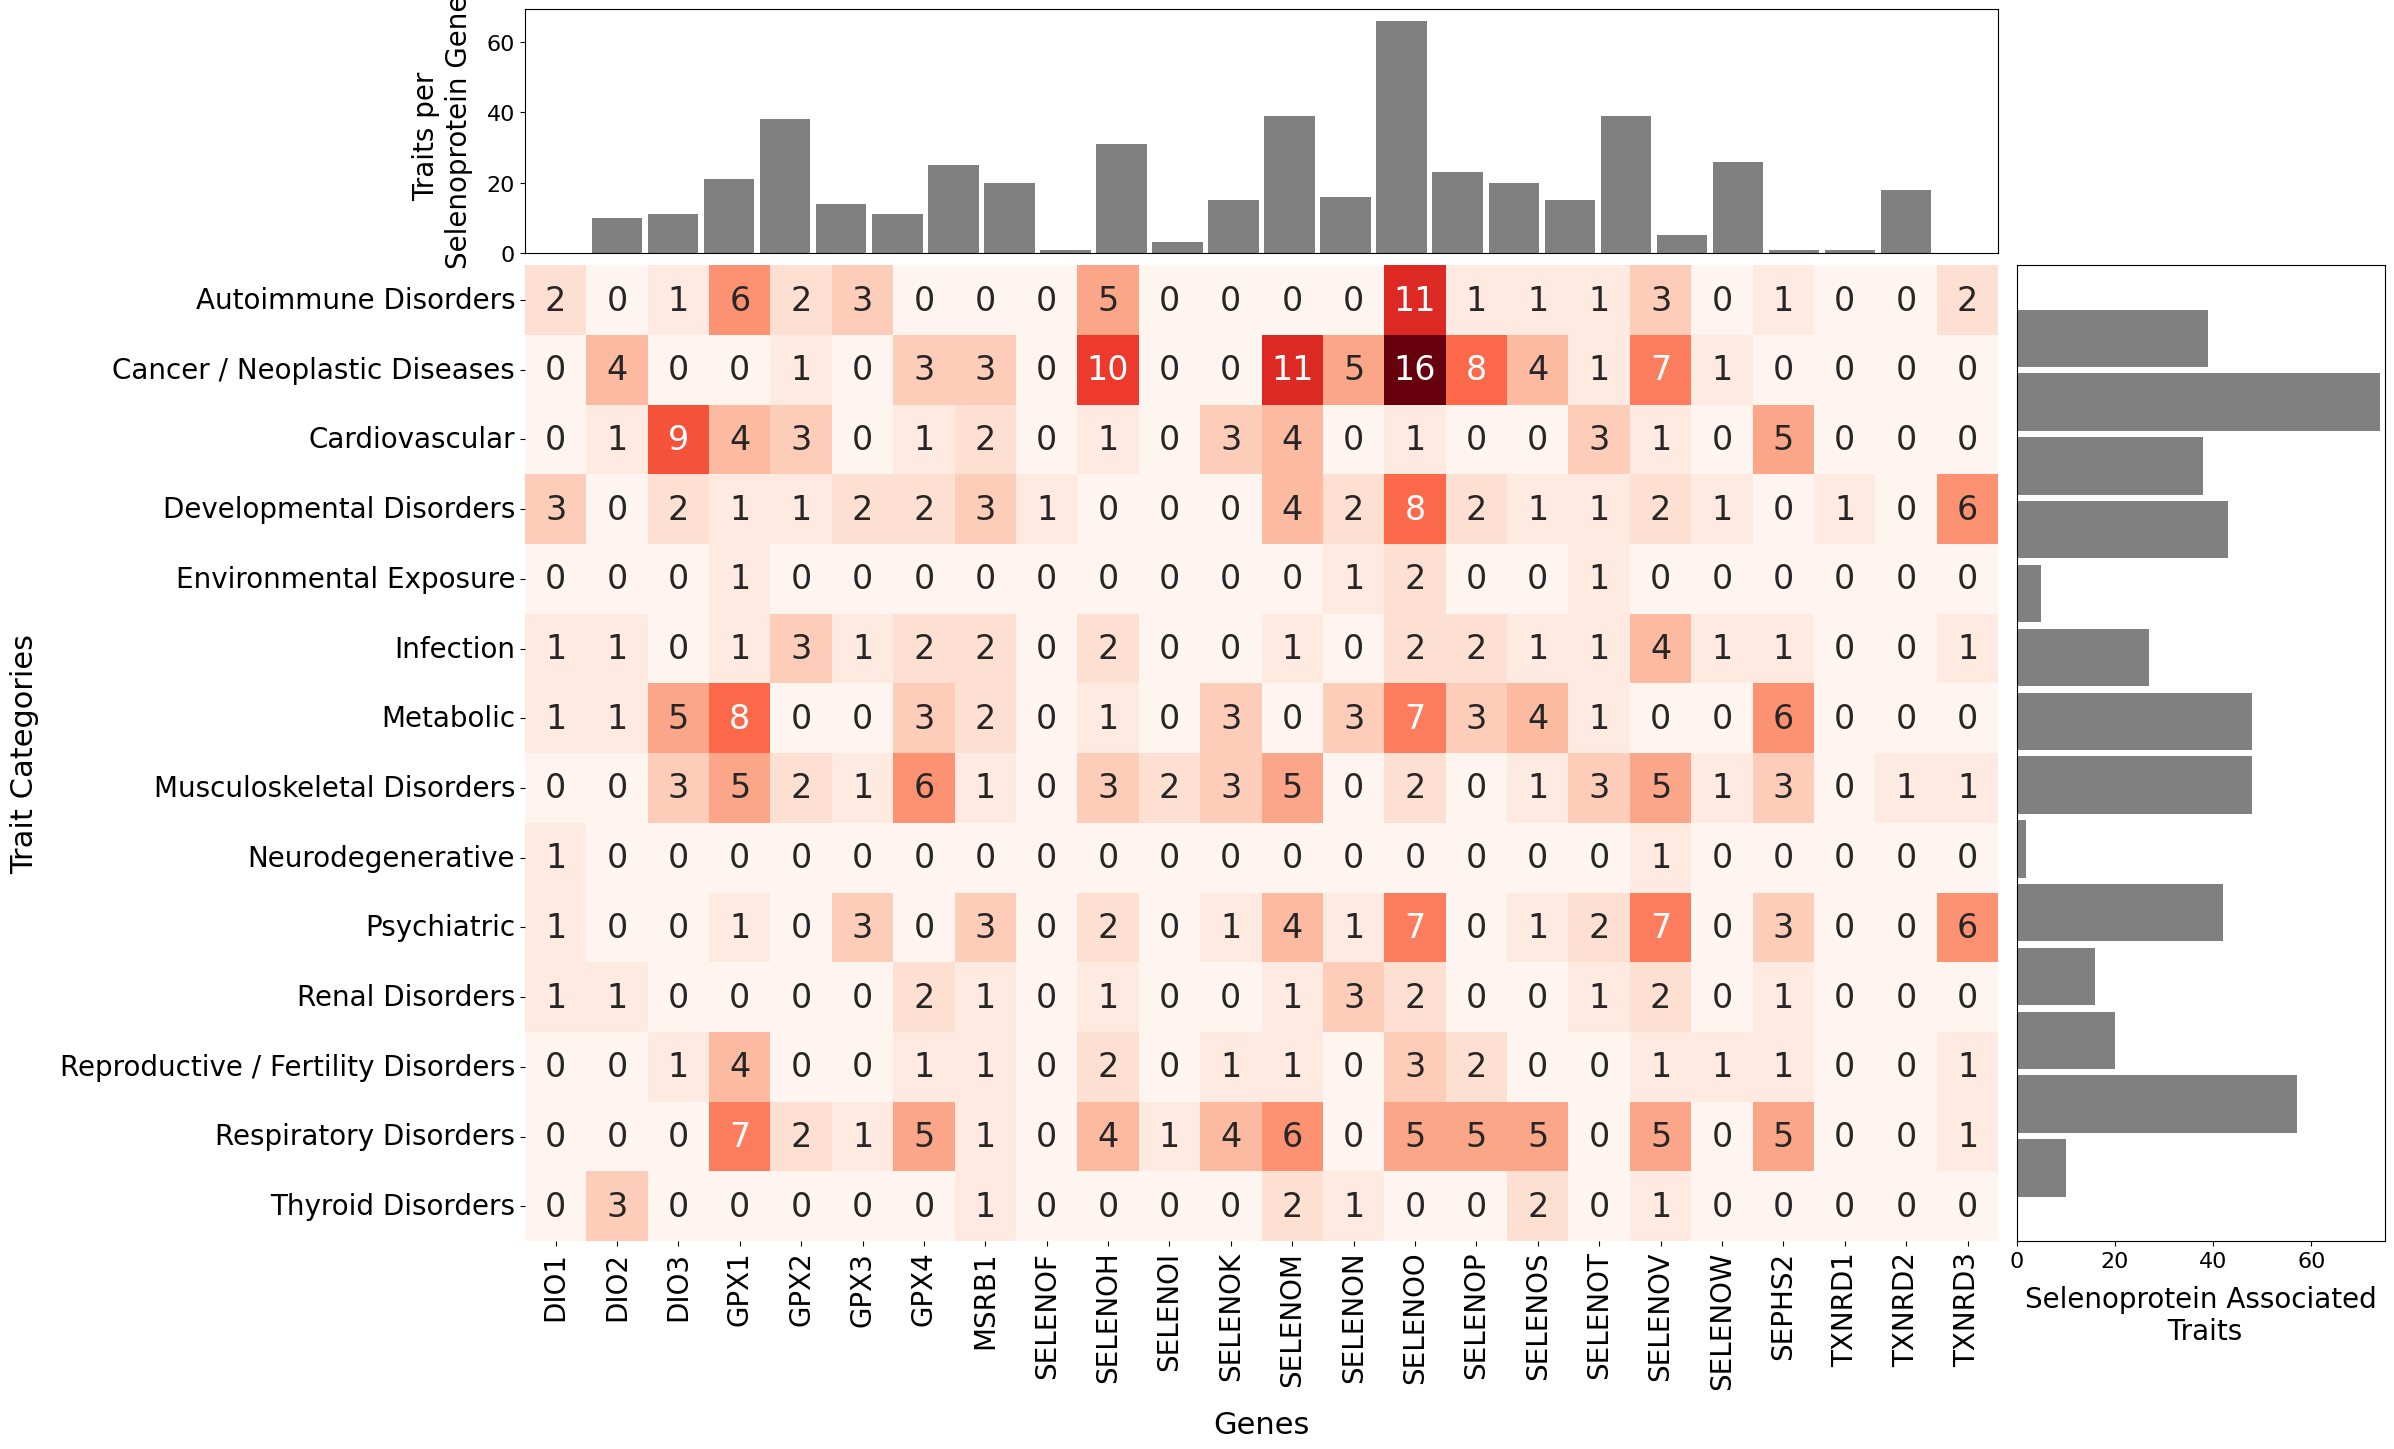

In [12]:
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Remove unassigned traits
df = df[df['Predicted_Category'] != 'Unassigned']
df = df[df['Predicted_Category'] != 'Medication']
df = df[df['Predicted_Category'] != 'Diet']
df = df[df['Predicted_Category'] != 'General Health / Anthropometric']
df = df[df['Predicted_Category'] != 'Lifestyle / Behavioral']
df = df[df['Predicted_Category'] != 'Socioeconomic / Demographic']

# Expand rows with multiple genes
df_expanded = df.assign(regulatory_list=df['regulatory list'].str.split(',')).explode('regulatory_list')
df_expanded['regulatory_list'] = df_expanded['regulatory_list'].str.strip()

# Pivot table for heatmap
heatmap_data = pd.crosstab(df_expanded['Predicted_Category'], df_expanded['regulatory_list'])

# Marginal counts
y_counts = heatmap_data.sum(axis=1)  # genes per category
x_counts = heatmap_data.sum(axis=0)  # categories per gene

# Figure and GridSpec: make width/height ratios larger for bars
fig = plt.figure(figsize=(24, 16))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.0, 0.25], height_ratios=[0.25, 1.0],
                       wspace=0.02, hspace=0.02)

# Heatmap
ax_heatmap = fig.add_subplot(gs[1, 0])
sns.heatmap(
    heatmap_data, cmap='Reds', annot=True, cbar=False, ax=ax_heatmap,
    annot_kws={"fontsize": 24}
)

# Cell positions
x_pos = [i + 0.5 for i in range(heatmap_data.shape[1])]
y_pos = [i + 0.5 for i in range(heatmap_data.shape[0])]

# Top bar chart using slightly wider bars
ax_top = fig.add_subplot(gs[0, 0])
ax_top.bar(x_pos, x_counts.values, width=0.9, color='gray', align='center')
ax_top.set_xticks([])
ax_top.set_ylabel('Traits per \nSelenoprotein Gene', fontsize=20, labelpad=10)
ax_top.tick_params(axis='y', labelsize=16)

# Right-hand side using broken_barh for exact alignment
ax_right = fig.add_subplot(gs[1, 1])
#ax_right.bar(y_pos, y_counts.values, width=0.9, color='gray', align='center')
for i, val in enumerate(y_counts.values):
    ax_right.broken_barh([(0, val)], (i, 0.9), facecolors='gray')
ax_right.set_yticks([])
ax_right.set_xlabel('Selenoprotein Associated\n Traits', fontsize=20, labelpad=10)
ax_right.tick_params(axis='x', labelsize=16)
ax_right.set_xlim(0, max(y_counts)+1)
ax_right.invert_yaxis()

# Heatmap axis labels
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=90, fontsize=20)
ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), rotation=0, fontsize=20)
ax_heatmap.set_xlabel("Genes", fontsize=22, labelpad=15)
ax_heatmap.set_ylabel("Trait Categories", fontsize=22, labelpad=15)


plt.tight_layout()
plt.savefig("/Users/iseult/Desktop/Trait_Assignment/regulatory_trait_associations_better.pdf")
plt.show()

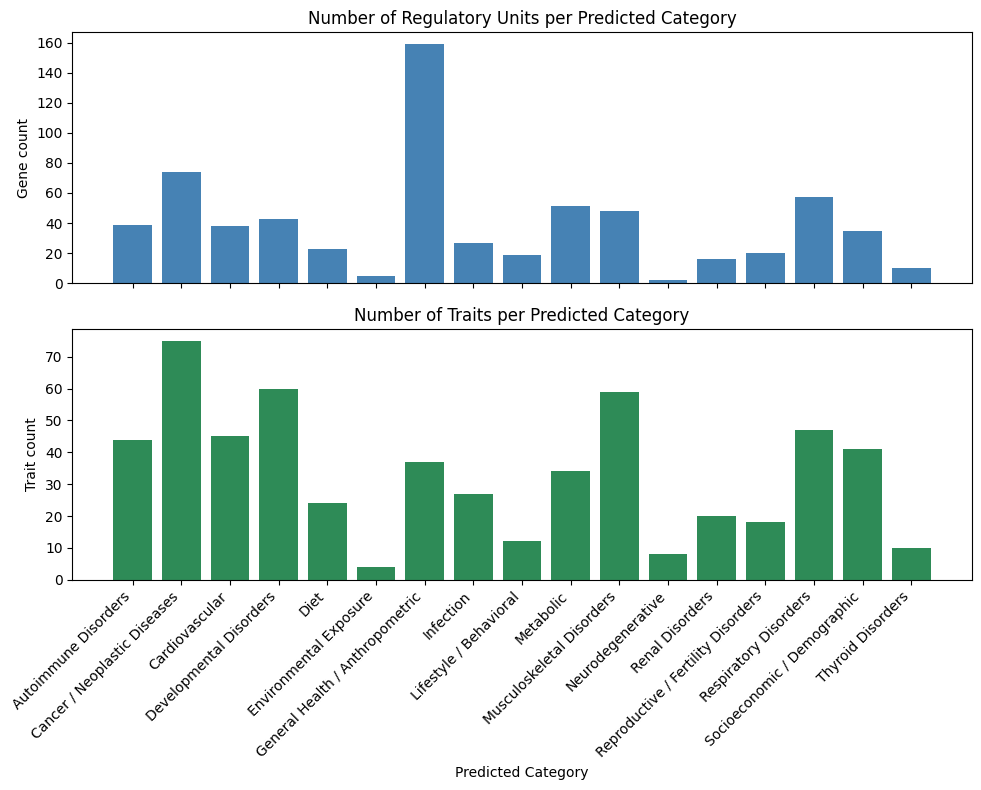

In [10]:
df_expanded = df_expanded[df_expanded['Predicted_Category'] != 'Unassigned']

# --- 1️⃣ Count genes per category ---
# Since coding_list is a single gene per row after expansion,
# just count how many rows per category
gene_counts = df_expanded.groupby("Predicted_Category")["regulatory_list"].nunique()  # counts unique genes per category
# alternatively, if duplicates across traits are allowed, use .count()
gene_counts_all = df_expanded.groupby("Predicted_Category")["regulatory_list"].count()

# --- 2️⃣ Count traits per category ---
trait_counts = df_expanded.groupby("Predicted_Category")["title"].nunique()

# --- 3️⃣ Combine for plotting ---
counts_df = pd.DataFrame({
    "Regulatory count": gene_counts_all,
    "Trait count": trait_counts
}).fillna(0)

# --- 4️⃣ Plot two stacked histograms (shared x-axis) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gene count histogram
axes[0].bar(counts_df.index, counts_df["Regulatory count"], color="steelblue")
axes[0].set_title("Number of Regulatory Units per Predicted Category")
axes[0].set_ylabel("Gene count")

# Trait count histogram
axes[1].bar(counts_df.index, counts_df["Trait count"], color="seagreen")
axes[1].set_title("Number of Traits per Predicted Category")
axes[1].set_ylabel("Trait count")

# Shared x-axis label
plt.xticks(rotation=45, ha="right")
plt.xlabel("Predicted Category")

plt.tight_layout()
plt.show()


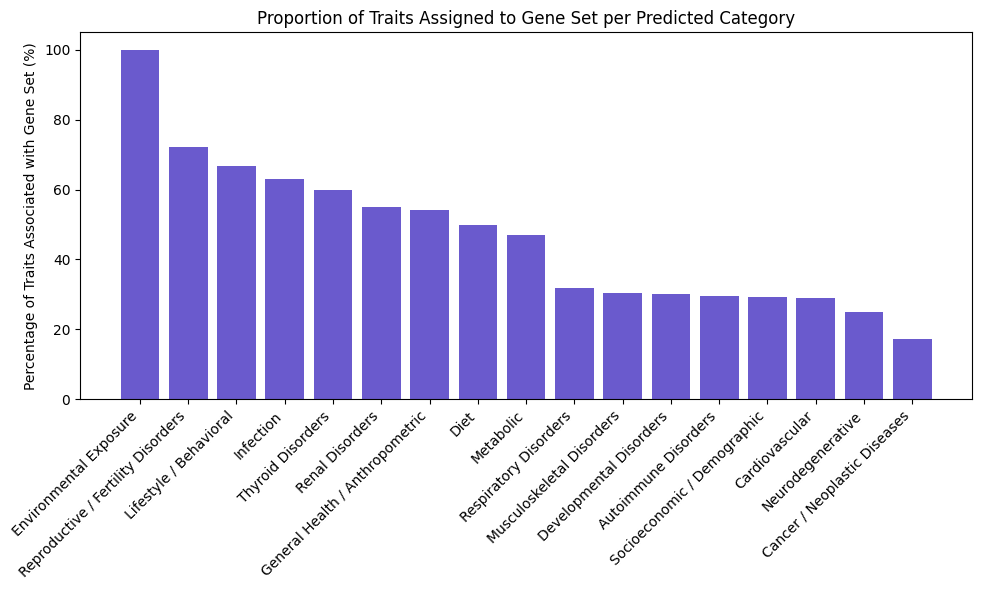

In [11]:
# --- Count genes and traits per Predicted_Category ---
gene_counts = df_expanded.groupby("Predicted_Category")["regulatory_list"].nunique()
trait_counts = df_expanded.groupby("Predicted_Category")["title"].nunique()

# --- Compute percentage ---
percentage_df = (gene_counts / trait_counts * 100).fillna(0).sort_values(ascending=False)

# --- Plot percentage histogram ---
plt.figure(figsize=(10, 6))
plt.bar(percentage_df.index, percentage_df.values, color="slateblue")
plt.ylabel("Percentage of Traits Associated with Gene Set (%)")
plt.title("Proportion of Traits Assigned to Gene Set per Predicted Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [12]:
def query(df, gene, trait):
    """
    Returns the titles for a specific gene and trait category combination.
    """
    # Clean up and expand the regulatory list just like before
    df_expanded = df.assign(regulatory_list=df['regulatory list'].str.split(',')).explode('regulatory_list')
    df_expanded['regulatory_list'] = df_expanded['regulatory_list'].str.strip()

    # Filter by the specified gene and trait
    result = df_expanded[
        (df_expanded['Predicted_Category'].str.lower() == trait.lower()) &
        (df_expanded['regulatory_list'].str.lower() == gene.lower())
    ]

    if result.empty:
        print(f"No matches found for gene '{gene}' and trait '{trait}'.")
    else:
        print(f"Matches for gene '{gene}' and trait '{trait}':\n")
        for t in result['title'].unique():
            print(f"• {t}")

    print("\n")
    return result

query(df, "SELENON", "Developmental Disorders")
query(df, "TXNRD3", "Reproductive / Fertility Disorders")

Matches for gene 'SELENON' and trait 'Developmental Disorders':

• Diagnoses - main ICD10: G51 Facial nerve disorders
• Bell's palsy


Matches for gene 'TXNRD3' and trait 'Reproductive / Fertility Disorders':

• Diagnoses - main ICD10: N93 Other abnormal uterine and vaginal bleeding




,Study,title,coding genes,coding list,regulatory genes,regulatory list,Predicted_Category,Category_Similarity,regulatory_list
1074,UKBB,Diagnoses - main ICD10: N93 Other abnormal ute...,0,NaN,1,TXNRD3,Reproductive / Fertility Disorders,0.327046,TXNRD3
